# I-JEPA Semantic Image Clustering

## Controlled Evaluation of Unsupervised Visual Organization

This notebook evaluates whether embeddings produced by the pretrained
I-JEPA vision encoder contain useful semantic structure for unsupervised
image organization.

The experiment uses a manually curated dataset containing **480 images
across 8 visual categories**, with 60 images per category:

- mountains
- boats
- flowers
- cars
- shark
- snake
- cat
- dog

The category/folder labels are used **only for post-hoc evaluation**. They
are never provided to I-JEPA, UMAP, or HDBSCAN during representation
learning or clustering — from the model's perspective, the entire pipeline
is unsupervised.

The pipeline is:

```text
Image
   |
I-JEPA
   |
1280-D embedding
   |
L2 normalization
   |
UMAP
   |
HDBSCAN
   |
cluster evaluation
```

## Objectives

This experiment investigates four questions:

1. **Representation quality:** do I-JEPA embeddings preserve meaningful
   visual similarity?
2. **Local semantic retrieval:** do nearest neighbors in embedding space
   share visual semantics?
3. **Unsupervised clustering:** can UMAP + HDBSCAN recover meaningful
   category-level structure from those embeddings without ever seeing the
   category labels?
4. **Parameter sensitivity:** how sensitive is the resulting clustering to
   UMAP/HDBSCAN configuration?

The experiment is designed as a controlled evaluation of the representation
and clustering pipeline, rather than as supervised classification.


## 1. Motivation

Unsupervised clustering pipelines built on top of pretrained visual
encoders are attractive for organizing large, unlabeled photo collections,
but it is not obvious in advance whether a general-purpose encoder such as
I-JEPA produces embeddings with enough category-level structure for a
generic pipeline (UMAP dimensionality reduction followed by HDBSCAN
density-based clustering) to recover that structure without supervision.

A manually curated, category-balanced dataset removes label ambiguity and
class imbalance as confounding factors, which makes it possible to isolate
the properties of the representation and the clustering pipeline
themselves.

This experiment evaluates:

1. **Representation quality** — whether I-JEPA embeddings separate visually
   and semantically distinct categories.
2. **Local semantic retrieval** — whether nearest-neighbor search in
   embedding space returns visually related images.
3. **Unsupervised clustering** — whether HDBSCAN, applied to a UMAP
   projection of the embeddings, recovers cluster structure that agrees
   with the (held-out) category labels.
4. **Clustering sensitivity** — how much the clustering result changes
   under different UMAP/HDBSCAN configurations.

The category labels are used only to *evaluate* the resulting clusters
after the fact; they play no role in producing the embeddings, the UMAP
projection, or the HDBSCAN clustering itself.


## Environment

The experiment uses PyTorch and Hugging Face Transformers for I-JEPA
inference, together with UMAP and HDBSCAN for dimensionality reduction and
unsupervised clustering.

The dataset labels are derived entirely from the folder structure; no external
metadata or keyword labels are used.


In [27]:
# Install and import required third-party packages
import importlib
import subprocess
import sys


def ensure(package: str, import_name: str | None = None) -> None:
    name = import_name or package
    try:
        importlib.import_module(name)
    except ImportError:
        print(f"Installing {package} ...")
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "-q", package, "--break-system-packages"],
            check=True,
        )


for pkg, imp in [
    ("pandas", "pandas"), ("Pillow", "PIL"), ("torch", "torch"),
    ("transformers", "transformers"), ("numpy", "numpy"), ("umap-learn", "umap"),
    ("hdbscan", "hdbscan"), ("scikit-learn", "sklearn"), ("matplotlib", "matplotlib"),
    ("tqdm", "tqdm"), ("seaborn", "seaborn"),
]:
    ensure(pkg, imp)


In [28]:
# Core imports used throughout the notebook
import hashlib
import json
import random
import time
import warnings
from collections import Counter
from dataclasses import dataclass, field
from pathlib import Path
from typing import Sequence

import hdbscan
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import umap
from IPython.display import display
from PIL import Image, UnidentifiedImageError
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score
from tqdm.auto import tqdm
from transformers import AutoModel, AutoProcessor

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: cuda


In [29]:
SEED = 42               # global reproducibility seed
CONTROLLED_SEED = 42    # governs sampling for visual sanity checks etc. in this notebook


def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_global_seed(SEED)
print(f"SEED={SEED}  CONTROLLED_SEED={CONTROLLED_SEED}")


SEED=42  CONTROLLED_SEED=42


## 2. Controlled Dataset Configuration

The experiment uses a manually curated image dataset organized into one
folder per evaluation category:

```text
controlled_dataset/
├── mountains/
├── boats/
├── flowers/
├── cars/
├── shark/
├── snake/
├── cat/
└── dog/
```

The target dataset contains:

**8 categories × 60 images = 480 images**

The folder name provides the ground-truth category used only for evaluation.

The data-loading pipeline discovers the categories and image files from the
directory structure rather than relying on a hard-coded image list.


In [30]:
EXPECTED_NUM_CATEGORIES = 8
EXPECTED_IMAGES_PER_CATEGORY = 60
EXPECTED_TOTAL_IMAGES = EXPECTED_NUM_CATEGORIES * EXPECTED_IMAGES_PER_CATEGORY

VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".webp")


def find_project_root(start: Path | None = None) -> Path:
    """Find the project root containing the controlled dataset."""
    start = (start or Path.cwd()).resolve()

    for candidate in (start, *start.parents):
        if (candidate / "controlled_dataset").exists():
            return candidate

    return start


@dataclass
class Config:
    project_root: Path = field(default_factory=find_project_root)
    controlled_dataset_dir: Path = None   # controlled_dataset/ -- manually labeled images, folder = label
    embeddings_dir: Path = None           # dedicated cache location for this experiment's embeddings
    metadata_dir: Path = None

    model_id: str = "facebook/ijepa_vith14_1k"
    batch_size: int = 16

    # Baseline UMAP/HDBSCAN parameters, run first and unmodified (Sections 10-11)
    umap_n_neighbors: int = 15
    umap_min_dist: float = 0.1
    umap_n_components_viz: int = 2
    umap_n_components_cluster: int = 10
    hdbscan_min_cluster_size: int = 10
    hdbscan_min_samples: int = 5

    def __post_init__(self):
        self.controlled_dataset_dir = self.controlled_dataset_dir or self.project_root / "controlled_dataset"
        self.embeddings_dir = self.embeddings_dir or self.project_root / "data" / "embeddings" / "controlled_manual"
        self.metadata_dir = self.metadata_dir or self.project_root / "data" / "metadata"
        for d in (self.embeddings_dir, self.metadata_dir):
            d.mkdir(parents=True, exist_ok=True)


CFG = Config()
print(f"controlled_dataset_dir: {CFG.controlled_dataset_dir}")
print(f"embeddings_dir:         {CFG.embeddings_dir}")
print(f"Expected: {EXPECTED_NUM_CATEGORIES} categories x {EXPECTED_IMAGES_PER_CATEGORY} images "
      f"= {EXPECTED_TOTAL_IMAGES} images total")

if not CFG.controlled_dataset_dir.exists():
    raise FileNotFoundError(
        f"{CFG.controlled_dataset_dir} not found. Place the manually labeled dataset there "
        "(one subfolder per category) before continuing."
    )


controlled_dataset_dir: C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\controlled_dataset
embeddings_dir:         C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\embeddings\controlled_manual
Expected: 8 categories x 60 images = 480 images total


## 3. Dataset Discovery

Categories are discovered from the subdirectories of
`controlled_dataset/`.

Each image receives a stable identifier derived from its category and filename.
This identifier is used throughout the embedding and evaluation pipeline,
rather than relying on dataframe row order.

The discovery step also reports missing, unexpected, or renamed categories
before the experiment proceeds.


In [31]:
def discover_categories(root: Path) -> list[str]:
    return sorted(p.name for p in root.iterdir() if p.is_dir())


def make_stable_id(category: str, file_path: Path) -> str:
    stem = file_path.stem  # filename without extension
    return f"{category}__{stem}"


def discover_controlled_dataset(root: Path, valid_extensions: tuple) -> pd.DataFrame:
    categories = discover_categories(root)
    rows = []
    for cat in categories:
        cat_dir = root / cat
        for f in sorted(cat_dir.iterdir()):
            if f.is_file() and f.suffix.lower() in valid_extensions:
                rows.append({
                    "photo_id": make_stable_id(cat, f),
                    "path": f,
                    "evaluation_category": cat,
                    "extension": f.suffix.lower(),
                })
    return pd.DataFrame(rows)


discovered_categories = discover_categories(CFG.controlled_dataset_dir)
print(f"Discovered categories ({len(discovered_categories)}): {discovered_categories}")

expected_set = {"mountains", "boats", "flowers", "cars", "shark", "snake", "cat", "dog"}
actual_set = set(discovered_categories)
if actual_set != expected_set:
    print(f"\nNOTE: discovered categories differ from the expected set.")
    print(f"  Missing (expected but not found): {sorted(expected_set - actual_set)}")
    print(f"  Extra   (found but not expected):  {sorted(actual_set - expected_set)}")
else:
    print("Discovered categories match the expected set exactly.")

df_controlled_raw = discover_controlled_dataset(CFG.controlled_dataset_dir, VALID_EXTENSIONS)
print(f"\nTotal image files discovered (before validation): {len(df_controlled_raw)}")
assert df_controlled_raw["photo_id"].is_unique, "Stable IDs collided -- check for duplicate filenames within a category."
display(df_controlled_raw.head())

Discovered categories (8): ['boats', 'cars', 'cat', 'dog', 'flowers', 'mountains', 'shark', 'snake']
Discovered categories match the expected set exactly.

Total image files discovered (before validation): 480


,photo_id,path,evaluation_category,extension
0,boats__1,C:\Users\aryan\OneDrive\Desktop\project_new\se...,boats,.jpg
1,boats__10,C:\Users\aryan\OneDrive\Desktop\project_new\se...,boats,.jpg
2,boats__11,C:\Users\aryan\OneDrive\Desktop\project_new\se...,boats,.jpg
3,boats__12,C:\Users\aryan\OneDrive\Desktop\project_new\se...,boats,.jpg
4,boats__13,C:\Users\aryan\OneDrive\Desktop\project_new\se...,boats,.jpg


## 4. Dataset Validation

Before running I-JEPA inference, every image is checked for:

- file existence
- image readability and decoding
- expected category membership
- expected number of images per category
- file extension
- image dimensions

The experiment is expected to contain **480 usable images**, with exactly
60 images in each of the 8 categories.


In [32]:
# Validate every discovered image before running inference
def is_valid_image(path: Path) -> bool:
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            img.convert("RGB").load()
        return True
    except (UnidentifiedImageError, OSError, ValueError):
        return False


def validate_controlled_dataset(df: pd.DataFrame) -> pd.DataFrame:
    rows = []
    for r in tqdm(df.itertuples(index=False), total=len(df), desc="Validating"):
        exists = r.path.exists()
        valid = exists and is_valid_image(r.path)
        w = h = None
        if valid:
            with Image.open(r.path) as img:
                w, h = img.size
        rows.append({"photo_id": r.photo_id, "exists": exists, "valid_image": valid, "width": w, "height": h})
    return df.merge(pd.DataFrame(rows), on="photo_id", how="left")


df_controlled_validated = validate_controlled_dataset(df_controlled_raw)

missing = df_controlled_validated[~df_controlled_validated["exists"]]
corrupt = df_controlled_validated[df_controlled_validated["exists"] & ~df_controlled_validated["valid_image"]]
print(f"Missing files:            {len(missing)}")
print(f"Unreadable/corrupt files: {len(corrupt)}")
if len(missing):
    display(missing[["photo_id", "path"]])
if len(corrupt):
    display(corrupt[["photo_id", "path"]])

df_controlled = df_controlled_validated[df_controlled_validated["valid_image"]].reset_index(drop=True)
print(f"\nUsable images after validation: {len(df_controlled)} / {len(df_controlled_raw)} discovered")


Validating:   0%|          | 0/480 [00:00<?, ?it/s]

Missing files:            0
Unreadable/corrupt files: 0

Usable images after validation: 480 / 480 discovered


In [33]:
category_counts = df_controlled.groupby("evaluation_category").size().rename("n_usable_images").reset_index()
category_counts["expected"] = EXPECTED_IMAGES_PER_CATEGORY
category_counts["meets_expected"] = category_counts["n_usable_images"] == EXPECTED_IMAGES_PER_CATEGORY
display(category_counts)

print(f"\nTotal usable images: {len(df_controlled)}  (expected {EXPECTED_TOTAL_IMAGES})")
if len(df_controlled) != EXPECTED_TOTAL_IMAGES:
    print(f"WARNING: total usable image count ({len(df_controlled)}) does not match the expected "
          f"{EXPECTED_TOTAL_IMAGES}. Proceeding with the actual data, not the expected numbers.")
if not category_counts["meets_expected"].all():
    short = category_counts[~category_counts["meets_expected"]]
    print(f"\nWARNING: the following categories do not have exactly "
          f"{EXPECTED_IMAGES_PER_CATEGORY} usable images:")
    display(short)
else:
    print(f"\nEvery category has exactly {EXPECTED_IMAGES_PER_CATEGORY} usable images, as expected.")

print("\nFile extensions found:")
display(df_controlled["extension"].value_counts())

print("\nImage dimensions:")
display(df_controlled[["width", "height"]].describe())

,evaluation_category,n_usable_images,expected,meets_expected
0,boats,60,60,True
1,cars,60,60,True
2,cat,60,60,True
3,dog,60,60,True
4,flowers,60,60,True
5,mountains,60,60,True
6,shark,60,60,True
7,snake,60,60,True



Total usable images: 480  (expected 480)

Every category has exactly 60 usable images, as expected.

File extensions found:


extension
.jpg     470
.png       6
.jpeg      4
Name: count, dtype: int64


Image dimensions:


,width,height
count,480.000000,480.000000
mean,857.202083,660.135417
std,788.845132,669.812700
min,159.000000,133.000000
25%,275.000000,240.000000
50%,565.000000,376.000000
75%,1280.000000,853.000000
max,4334.000000,4624.000000


In [34]:
controlled_manifest_path = CFG.metadata_dir / "controlled_manual_manifest.csv"
df_controlled[["photo_id", "path", "evaluation_category"]].assign(
    local_path=lambda d: d["path"].astype(str)
)[["photo_id", "local_path", "evaluation_category"]].to_csv(controlled_manifest_path, index=False)
print(f"Manifest saved -> {controlled_manifest_path}")

Manifest saved -> C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\metadata\controlled_manual_manifest.csv


## 5. Visual Category Sanity Check

Random samples from each category are displayed to verify that the manually
curated dataset matches its intended category structure.

This visualization is a dataset-quality check only. Category labels are not
used to modify or transform the images.


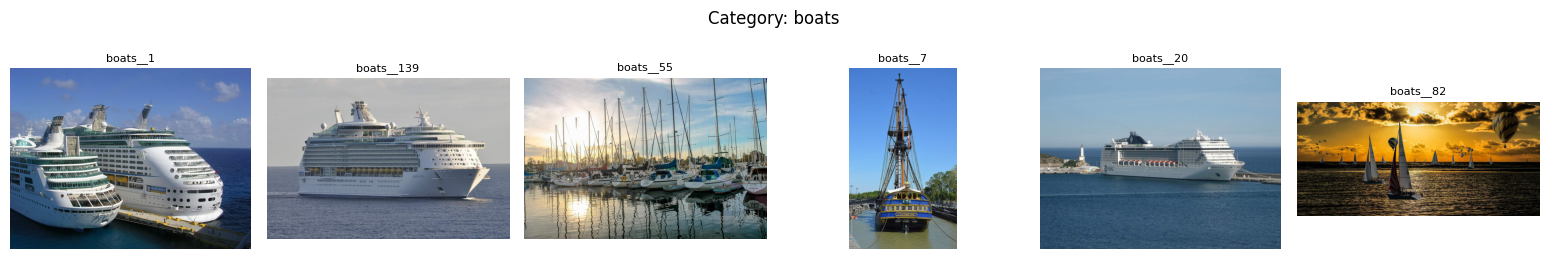

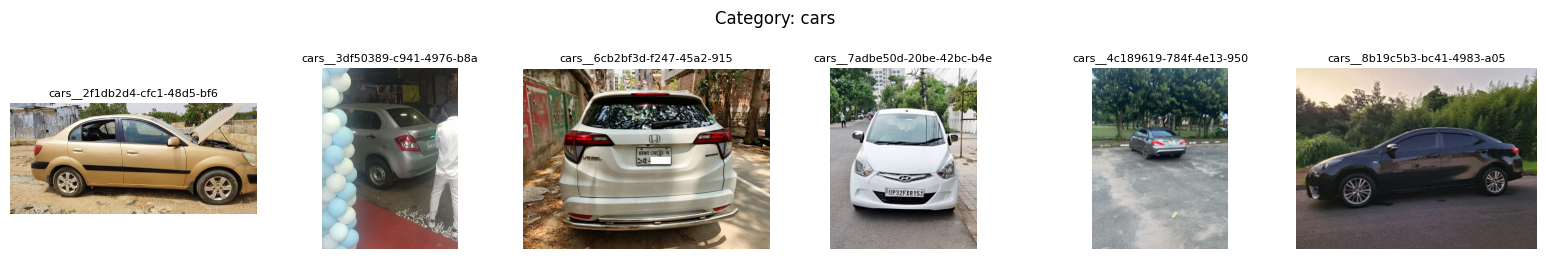

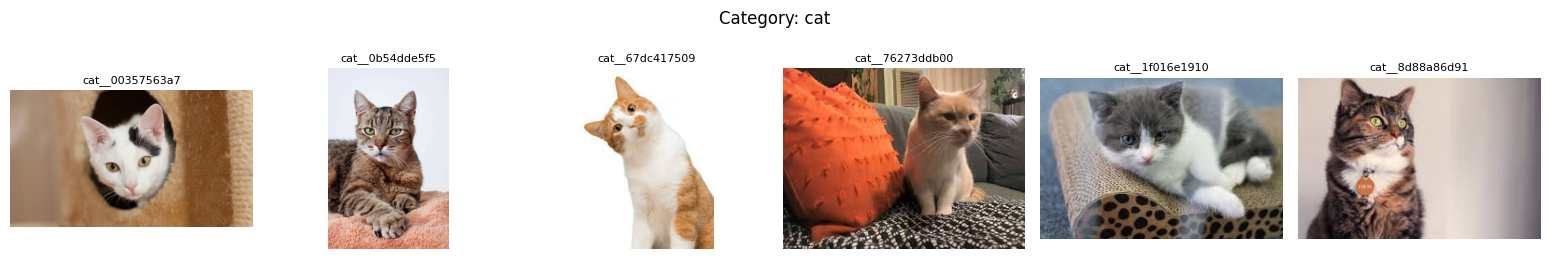

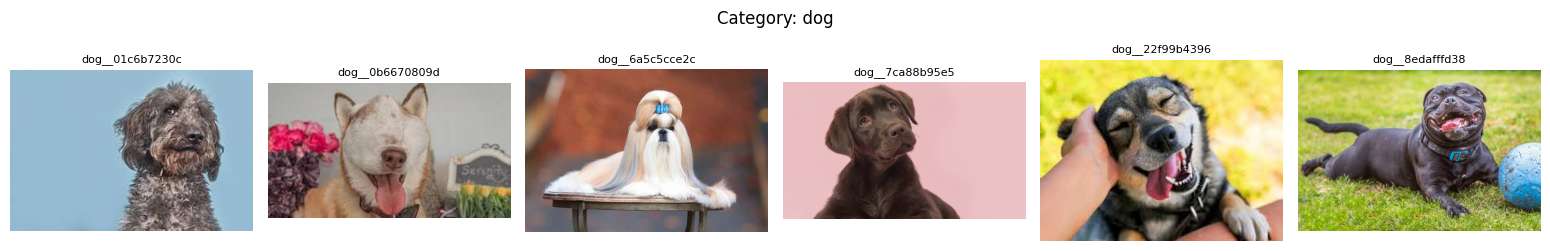

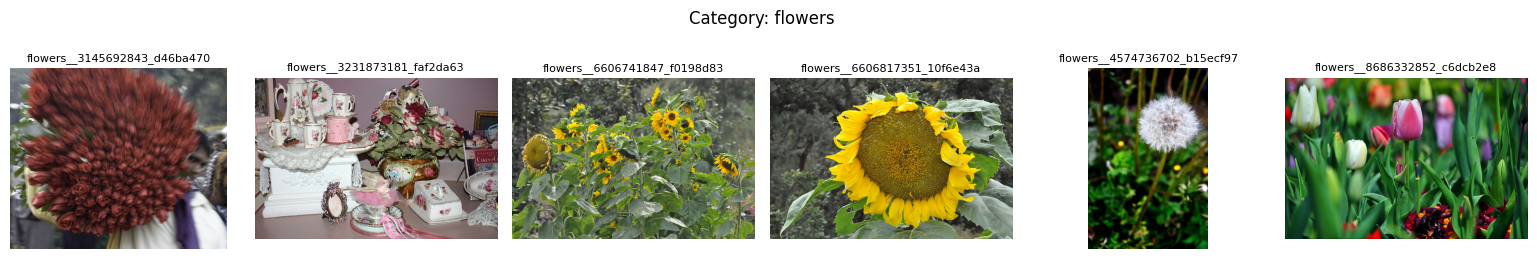

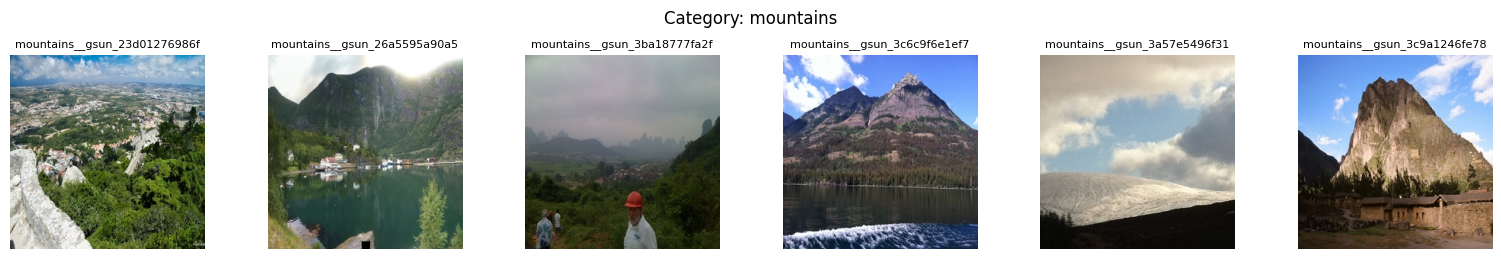

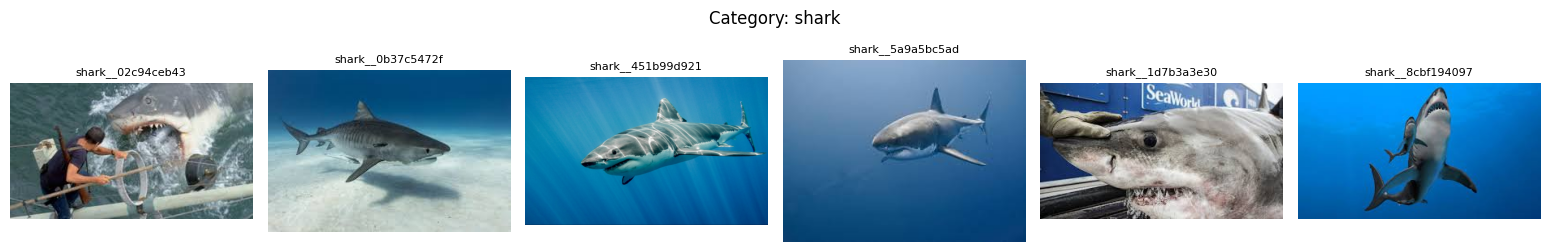

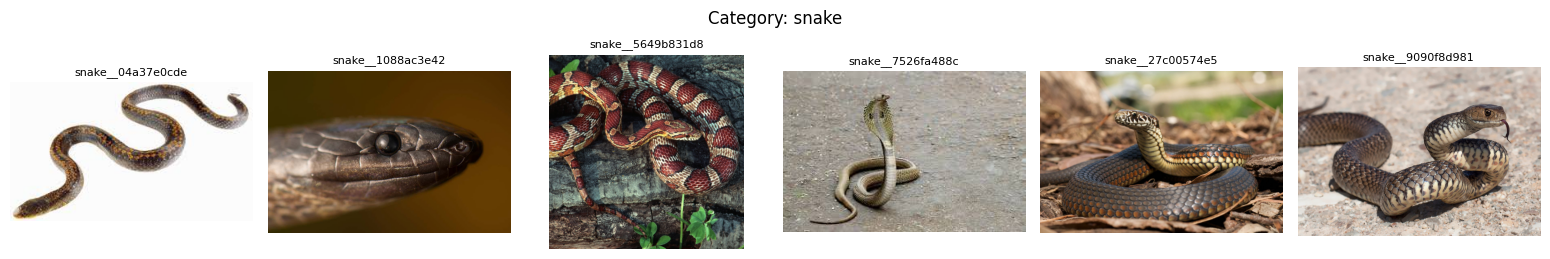

In [35]:
# Display a random sample grid of images per category for visual inspection
def show_image_grid(paths, titles=None, n_cols=5, figsize_per_cell=2.6, suptitle=None) -> None:
    n = len(paths)
    if n == 0:
        print("Nothing to show.")
        return
    n_cols = min(n_cols, n)
    n_rows = (n + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(figsize_per_cell * n_cols, figsize_per_cell * n_rows))
    axes = np.atleast_1d(axes).flatten()
    for i, ax in enumerate(axes):
        if i < n:
            try:
                img = Image.open(paths[i]).convert("RGB")
                ax.imshow(img)
            except Exception:
                ax.text(0.5, 0.5, "load error", ha="center", va="center")
            if titles is not None:
                ax.set_title(str(titles[i])[:28], fontsize=8)
        ax.axis("off")
    if suptitle:
        fig.suptitle(suptitle)
    plt.tight_layout()
    plt.show()


for cat in sorted(df_controlled["evaluation_category"].unique()):
    sample = df_controlled[df_controlled["evaluation_category"] == cat].sample(
        min(6, (df_controlled["evaluation_category"] == cat).sum()), random_state=CONTROLLED_SEED
    )
    show_image_grid(sample["path"].tolist(), titles=sample["photo_id"].tolist(),
                     n_cols=6, suptitle=f"Category: {cat}")


## 6. Load I-JEPA

The pretrained `facebook/ijepa_vith14_1k` checkpoint is loaded for image
representation extraction.

The model is used in evaluation mode with `torch.inference_mode()` so that
no parameters are updated during the experiment.


In [36]:
# Load the pretrained I-JEPA processor and model
MODEL_ID = CFG.model_id
print(f"Loading processor + model: {MODEL_ID}")

_t0 = time.time()
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModel.from_pretrained(MODEL_ID)
model.to(DEVICE)
model.eval()
print(f"Loaded in {time.time() - _t0:.1f}s")


def preprocess_batch(images: list[Image.Image]) -> dict:
    images = [img.convert("RGB") for img in images]
    inputs = processor(images=images, return_tensors="pt")
    return {k: v.to(DEVICE) for k, v in inputs.items()}


Loading processor + model: facebook/ijepa_vith14_1k


Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loaded in 10.8s


## 7. I-JEPA Embedding Extraction

Each image is passed through the pretrained I-JEPA encoder.

The model produces patch-level representations with hidden dimension 1280.
The patch representations are mean-pooled to obtain one fixed-size embedding
per image.

For 480 images, the expected embedding matrix is:

```text
480 × 1280
```

The embeddings are cached locally to avoid recomputing inference unnecessarily.


In [37]:
# Extract mean-pooled I-JEPA embeddings, with a local disk cache keyed by dataset fingerprint
def extract_embeddings(image_paths: list[Path], batch_size: int) -> np.ndarray:
    all_embeddings = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Embedding"):
        batch_paths = image_paths[i:i + batch_size]
        batch_imgs = [Image.open(p).convert("RGB") for p in batch_paths]
        inputs = preprocess_batch(batch_imgs)
        with torch.inference_mode():
            outputs = model(**inputs)
        pooled = outputs.last_hidden_state.mean(dim=1)
        all_embeddings.append(pooled.cpu().numpy())
    return np.concatenate(all_embeddings, axis=0) if all_embeddings else np.empty((0,))


def dataset_fingerprint(photo_ids: Sequence[str]) -> str:
    ids = "|".join(sorted(photo_ids))
    return hashlib.sha256(ids.encode()).hexdigest()[:16]


def get_or_compute_controlled_embeddings(df: pd.DataFrame) -> tuple[np.ndarray, pd.DataFrame]:
    fp = dataset_fingerprint(df["photo_id"].tolist())
    tag = CFG.model_id.replace("/", "__")
    emb_path = CFG.embeddings_dir / f"controlled_manual_{tag}_{fp}_embeddings.npy"
    ids_path = CFG.embeddings_dir / f"controlled_manual_{tag}_{fp}_photo_ids.json"

    if emb_path.exists() and ids_path.exists():
        cached_ids = json.loads(ids_path.read_text())
        if cached_ids == sorted(df["photo_id"].tolist()):
            print(f"Loading cached controlled embeddings from {emb_path}")
            emb = np.load(emb_path)
            df_sorted = df.set_index("photo_id").loc[cached_ids].reset_index()
            return emb, df_sorted

    print("No valid controlled-embedding cache found — computing.")
    df_sorted = df.sort_values("photo_id").reset_index(drop=True)
    emb = extract_embeddings(df_sorted["path"].tolist(), CFG.batch_size)
    np.save(emb_path, emb)
    ids_path.write_text(json.dumps(df_sorted["photo_id"].tolist()))
    print(f"Saved -> {emb_path}")
    return emb, df_sorted


_t0 = time.time()
controlled_embeddings, df_controlled = get_or_compute_controlled_embeddings(df_controlled)
CONTROLLED_EMBEDDING_SECONDS = time.time() - _t0
print(f"\nControlled embedding matrix: {controlled_embeddings.shape} in {CONTROLLED_EMBEDDING_SECONDS:.1f}s")

expected_shape = (EXPECTED_TOTAL_IMAGES, 1280)
if controlled_embeddings.shape != expected_shape:
    print(f"NOTE: embedding shape {controlled_embeddings.shape} differs from the "
          f"{expected_shape} expected for a full, clean 480-image / hidden_size=1280 run "
          f"(this is expected if validation in Section 4 dropped any images).")
else:
    print(f"Shape matches the expected {expected_shape}.")


Loading cached controlled embeddings from C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\embeddings\controlled_manual\controlled_manual_facebook__ijepa_vith14_1k_e779b0e01e6a080a_embeddings.npy

Controlled embedding matrix: (480, 1280) in 0.0s
Shape matches the expected (480, 1280).


## 8. Embedding Sanity Checks

The extracted embeddings are checked for:

- expected dimensionality
- numerical dtype
- NaN values
- infinite values
- embedding norm distribution

These checks ensure that the representation is numerically valid before
normalization and clustering.


In [38]:
# Check embedding shape, dtype, and norm distribution for numerical validity
def inspect_embeddings(emb: np.ndarray) -> None:
    norms = np.linalg.norm(emb, axis=1)
    print(f"Shape: {emb.shape}")
    print(f"Contains NaN: {np.isnan(emb).any()}   Contains Inf: {np.isinf(emb).any()}")
    print(f"Norm min/mean/max: {norms.min():.3f} / {norms.mean():.3f} / {norms.max():.3f}")


inspect_embeddings(controlled_embeddings)


Shape: (480, 1280)
Contains NaN: False   Contains Inf: False
Norm min/mean/max: 13.721 / 18.075 / 24.728


## 9. L2 Normalization

Each image embedding is L2-normalized to unit length.

For normalized vectors, the inner product is equivalent to cosine similarity:

\[
\cos(a,b) = a^\top b
\]

This normalized representation is used for downstream similarity analysis
and dimensionality reduction.


In [39]:
# L2-normalize embeddings so inner product equals cosine similarity
def l2_normalize(emb: np.ndarray) -> np.ndarray:
    norms = np.linalg.norm(emb, axis=1, keepdims=True)
    norms = np.where(norms == 0, 1e-12, norms)
    return emb / norms


controlled_embeddings_norm = l2_normalize(controlled_embeddings)
print(f"Post-normalization norm mean: {np.linalg.norm(controlled_embeddings_norm, axis=1).mean():.6f}")


Post-normalization norm mean: 1.000000


### Retrieval Sanity Check

Before clustering, one query image is selected from each category and its
top-5 nearest neighbors are retrieved using cosine similarity.

This provides a simple check of whether nearby points in the embedding space
tend to share visual semantics.

In [40]:
def quick_topk(query_idx: int, vecs: np.ndarray, k: int = 5):
    sims = vecs @ vecs[query_idx]
    sims[query_idx] = -np.inf
    top_idx = np.argsort(-sims)[:k]
    return top_idx, sims[top_idx]


rng_check = np.random.default_rng(CONTROLLED_SEED)
for cat in sorted(df_controlled["evaluation_category"].unique()):
    cat_idx = df_controlled.index[df_controlled["evaluation_category"] == cat].tolist()
    qi = int(rng_check.choice(cat_idx))
    top_idx, sims = quick_topk(qi, controlled_embeddings_norm, k=5)
    top_cats = df_controlled.iloc[top_idx]["evaluation_category"].tolist()
    match_rate = sum(c == cat for c in top_cats) / len(top_cats)
    print(f"Query category='{cat}' (photo_id={df_controlled.iloc[qi]['photo_id']}): "
          f"top-5 categories={top_cats}  same-category rate={match_rate:.0%}")

Query category='boats' (photo_id=boats__139): top-5 categories=['boats', 'boats', 'boats', 'boats', 'boats']  same-category rate=100%
Query category='cars' (photo_id=cars__7afb8742-6a25-491c-877a-5d8fe2446c32.jpg_7afb8742-6a25-491c-877a-5d8fe2446c32): top-5 categories=['cars', 'cars', 'cars', 'cars', 'cars']  same-category rate=100%
Query category='cat' (photo_id=cat__6edc079fcf): top-5 categories=['cat', 'cat', 'cat', 'cat', 'cat']  same-category rate=100%
Query category='dog' (photo_id=dog__4aacd195b5): top-5 categories=['dog', 'dog', 'dog', 'dog', 'dog']  same-category rate=100%
Query category='flowers' (photo_id=flowers__5459481183_18d2d49e44_m): top-5 categories=['flowers', 'flowers', 'flowers', 'flowers', 'flowers']  same-category rate=100%
Query category='mountains' (photo_id=mountains__gsun_3c86311aee8fd80f6200326db83776d9): top-5 categories=['mountains', 'mountains', 'mountains', 'mountains', 'mountains']  same-category rate=100%
Query category='shark' (photo_id=shark__0b37c54

## 10. UMAP Visualization

UMAP is used to project the normalized I-JEPA embeddings into a lower-
dimensional space for visualization and subsequent clustering.

The known category labels are used **only to color the visualization**.
They are never provided to UMAP during `fit_transform`.

The purpose of this visualization is to determine whether images from the
manually defined categories form visually distinguishable regions in the
learned representation space.


In [41]:
# Project normalized embeddings with UMAP: a 2D version for plotting, a higher-D version for clustering
def compute_umap_projection(emb_norm: np.ndarray, n_components: int, n_neighbors: int,
                             min_dist: float, seed: int) -> np.ndarray:
    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=min(n_neighbors, len(emb_norm) - 1),
        min_dist=min_dist,
        metric="cosine",
        random_state=seed,
    )
    return reducer.fit_transform(emb_norm)


_t0 = time.time()
umap_2d_baseline = compute_umap_projection(
    controlled_embeddings_norm, n_components=CFG.umap_n_components_viz,
    n_neighbors=CFG.umap_n_neighbors, min_dist=CFG.umap_min_dist, seed=SEED,
)
UMAP_VIZ_SECONDS = time.time() - _t0

_t0 = time.time()
umap_cluster_baseline = compute_umap_projection(
    controlled_embeddings_norm, n_components=CFG.umap_n_components_cluster,
    n_neighbors=CFG.umap_n_neighbors, min_dist=0.0, seed=SEED,
)
UMAP_CLUSTER_SECONDS = time.time() - _t0

df_controlled["umap_x"] = umap_2d_baseline[:, 0]
df_controlled["umap_y"] = umap_2d_baseline[:, 1]
print(f"UMAP (2D viz): {UMAP_VIZ_SECONDS:.1f}s   UMAP ({CFG.umap_n_components_cluster}D, clustering): {UMAP_CLUSTER_SECONDS:.1f}s")


c:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP (2D viz): 0.9s   UMAP (10D, clustering): 0.9s


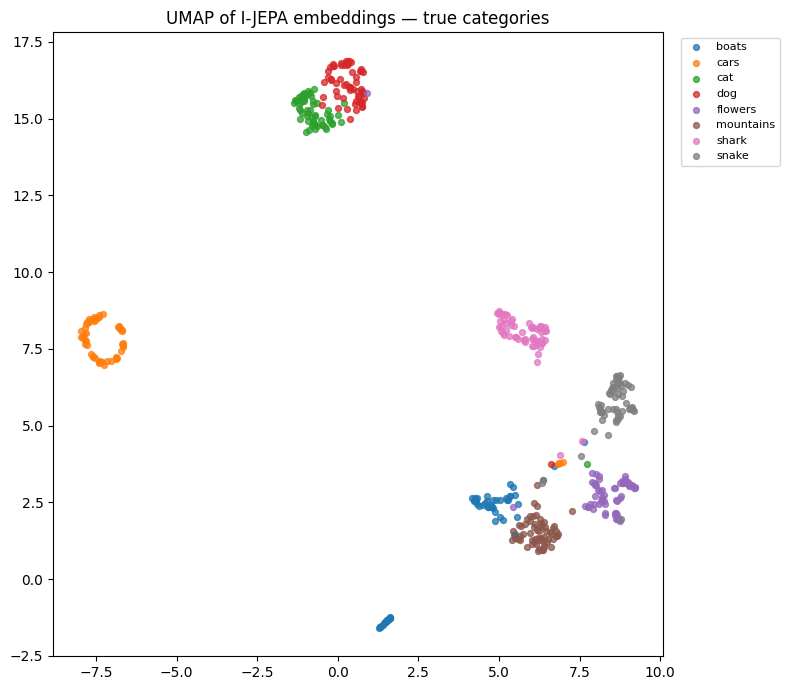

In [42]:
categories_sorted = sorted(df_controlled["evaluation_category"].unique())
palette = sns.color_palette("tab10", n_colors=len(categories_sorted))

fig, ax = plt.subplots(figsize=(8, 7))
for color, cat in zip(palette, categories_sorted):
    mask = df_controlled["evaluation_category"] == cat
    ax.scatter(df_controlled.loc[mask, "umap_x"], df_controlled.loc[mask, "umap_y"],
               s=18, alpha=0.75, color=color, label=cat)
ax.set_title("UMAP of I-JEPA embeddings — true categories")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**This plot answers: are the manually defined categories visually
separable in I-JEPA embedding space, before any clustering algorithm is
applied?** Clean, human-verified category labels remove label ambiguity as
a confounding factor: if categories still overlap heavily in this
projection, that is evidence toward a representation limitation rather
than a labeling-quality issue.


## 11. HDBSCAN Clustering

HDBSCAN is applied to the higher-dimensional UMAP projection to discover
clusters without being told the number of categories or the category
labels.

HDBSCAN does not require the number of clusters to be specified in advance,
and it is not constrained to produce exactly 8 clusters — points that do
not belong to any sufficiently dense cluster are labeled as noise (`-1`).


In [43]:
# Run HDBSCAN on the UMAP projection to discover clusters without using category labels
def run_hdbscan(features: np.ndarray, min_cluster_size: int, min_samples: int):
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean",
        cluster_selection_method="eom",
    )
    labels = clusterer.fit_predict(features)
    return labels, clusterer


_t0 = time.time()
baseline_labels, baseline_clusterer = run_hdbscan(
    umap_cluster_baseline, CFG.hdbscan_min_cluster_size, CFG.hdbscan_min_samples
)
HDBSCAN_BASELINE_SECONDS = time.time() - _t0
df_controlled["cluster_baseline"] = baseline_labels

n_clusters = len(set(baseline_labels) - {-1})
n_noise = int((baseline_labels == -1).sum())
print(f"HDBSCAN baseline: {HDBSCAN_BASELINE_SECONDS:.2f}s")
print(f"Clusters found: {n_clusters} (known categories: {len(categories_sorted)} -- not necessarily equal)")
print(f"Noise points:   {n_noise}/{len(df_controlled)} ({100 * n_noise / len(df_controlled):.1f}%)")
display(df_controlled["cluster_baseline"].value_counts().sort_index().to_frame("size"))


HDBSCAN baseline: 0.01s
Clusters found: 9 (known categories: 8 -- not necessarily equal)
Noise points:   7/480 (1.5%)


,size
cluster_baseline,
-1,7
0,27
1,29
2,119
3,58
4,19
5,55
6,72
7,61


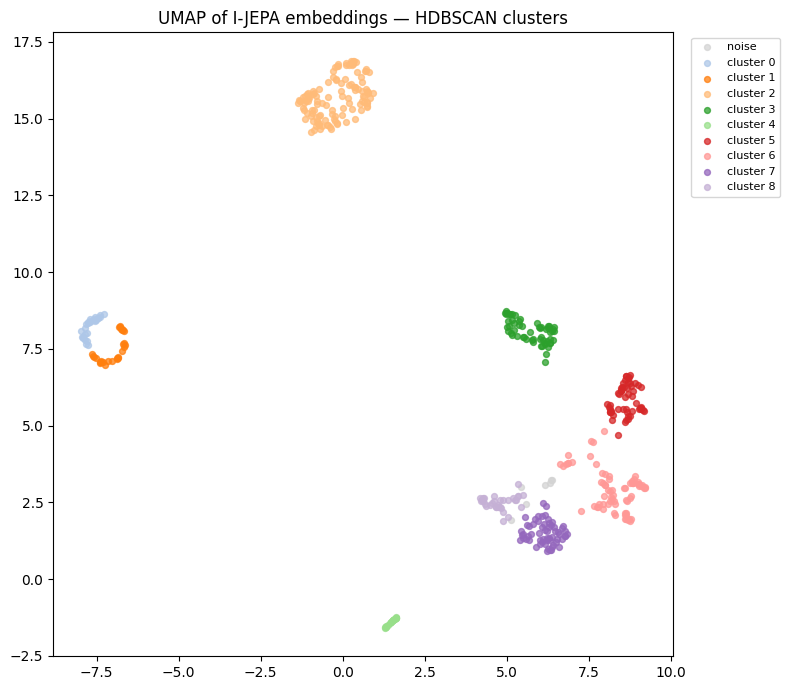

In [44]:
cluster_ids = sorted(df_controlled["cluster_baseline"].unique())
cluster_palette = sns.color_palette("tab20", n_colors=max(len(cluster_ids), 1))

fig, ax = plt.subplots(figsize=(8, 7))
for color, cid in zip(cluster_palette, cluster_ids):
    mask = df_controlled["cluster_baseline"] == cid
    label = "noise" if cid == -1 else f"cluster {cid}"
    c = "lightgray" if cid == -1 else color
    ax.scatter(df_controlled.loc[mask, "umap_x"], df_controlled.loc[mask, "umap_y"],
               s=18, alpha=0.75, color=c, label=label)
ax.set_title("UMAP of I-JEPA embeddings — HDBSCAN clusters")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

**Interpretation:** This visualization provides a qualitative view of class
structure in the embedding space before HDBSCAN clustering is applied.

Visible separation suggests that the representation contains category-level
structure, while substantial overlap indicates that the categories are not
globally separated in the learned embedding space.


## 12. Clustering Evaluation

The discovered HDBSCAN clusters are compared against the known folder
categories using three evaluation metrics:

- **Adjusted Rand Index (ARI):** measures agreement between clustering
  assignments while correcting for chance.
- **Normalized Mutual Information (NMI):** measures the shared information
  between the discovered clusters and known categories.
- **Cluster purity:** measures the dominant-category proportion within each
  discovered cluster.

The category labels are used only after clustering has finished.

Noise points (`-1`) are retained as a separate group for ARI and NMI.


In [45]:
def evaluate_clustering(true_labels: pd.Series, pred_labels: np.ndarray) -> dict:
    ari = adjusted_rand_score(true_labels, pred_labels)
    nmi = normalized_mutual_info_score(true_labels, pred_labels)
    return {"ARI": round(ari, 4), "NMI": round(nmi, 4)}


def cluster_purity_table(true_labels: pd.Series, pred_labels: np.ndarray) -> pd.DataFrame:
    df = pd.DataFrame({"true": true_labels.values, "pred": pred_labels})
    rows = []
    for cid in sorted(c for c in df["pred"].unique() if c != -1):
        members = df[df["pred"] == cid]
        top_cat, top_count = Counter(members["true"]).most_common(1)[0]
        rows.append({"cluster": cid, "n_images": len(members),
                      "dominant_category": top_cat, "purity": round(top_count / len(members), 3)})
    return pd.DataFrame(rows)


baseline_metrics = evaluate_clustering(df_controlled["evaluation_category"], baseline_labels)
print(f"Baseline ARI: {baseline_metrics['ARI']}   NMI: {baseline_metrics['NMI']}")
print("(0 -> no better than random grouping. 1 -> perfect agreement with the folder labels.)")

baseline_purity_df = cluster_purity_table(df_controlled["evaluation_category"], baseline_labels)
mean_purity = baseline_purity_df["purity"].mean() if len(baseline_purity_df) else float("nan")
print(f"\nMean cluster purity (excluding noise): {mean_purity:.3f}" if len(baseline_purity_df) else "\nNo non-noise clusters found.")
display(baseline_purity_df)

Baseline ARI: 0.7118   NMI: 0.8239
(0 -> no better than random grouping. 1 -> perfect agreement with the folder labels.)

Mean cluster purity (excluding noise): 0.914


,cluster,n_images,dominant_category,purity
0,0,27,cars,1.000
1,1,29,cars,1.000
2,2,119,cat,0.496
3,3,58,shark,1.000
4,4,19,boats,1.000
5,5,55,snake,1.000
6,6,72,flowers,0.806
7,7,61,mountains,0.951
8,8,33,boats,0.970


## 13. Cluster × Category Analysis

A cluster-by-category contingency table is used to inspect which semantic
categories are:

- recovered as distinct clusters,
- merged with visually similar categories, or
- split across multiple clusters.

This provides more detailed insight than ARI or NMI alone.


Contingency table (rows = HDBSCAN cluster, columns = known category; -1 = noise):


evaluation_category,boats,cars,cat,dog,flowers,mountains,shark,snake
cluster_baseline,,,,,,,,
-1,4,0,0,0,0,1,0,2
0,0,27,0,0,0,0,0,0
1,0,29,0,0,0,0,0,0
2,0,0,59,59,1,0,0,0
3,0,0,0,0,0,0,58,0
4,19,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,55
6,2,4,1,1,58,1,2,3
7,3,0,0,0,0,58,0,0


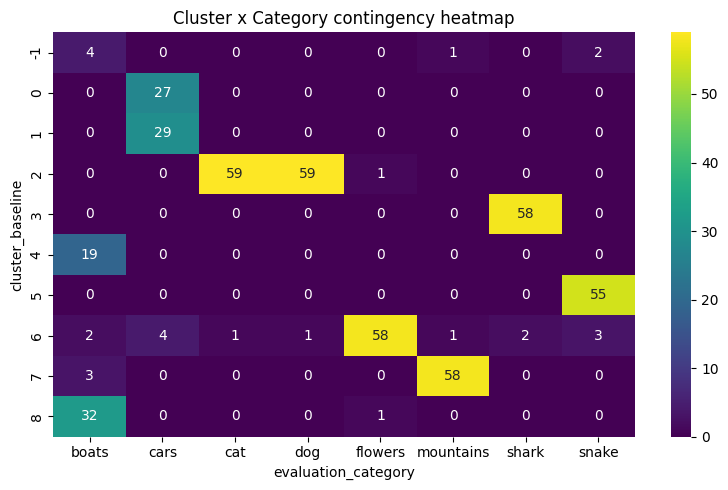

In [46]:
contingency = pd.crosstab(df_controlled["cluster_baseline"], df_controlled["evaluation_category"])
print("Contingency table (rows = HDBSCAN cluster, columns = known category; -1 = noise):")
display(contingency)

fig, ax = plt.subplots(figsize=(8, max(4, 0.5 * len(contingency))))
sns.heatmap(contingency, annot=True, fmt="d", cmap="viridis", ax=ax)
ax.set_title("Cluster x Category contingency heatmap")
ax.set_xlabel("evaluation_category")
ax.set_ylabel("cluster_baseline")
plt.tight_layout()
plt.show()

In [47]:
def category_wise_behavior(df: pd.DataFrame, cluster_col: str) -> pd.DataFrame:
    rows = []
    for cat, group in df.groupby("evaluation_category"):
        dist = group[cluster_col].value_counts()
        dominant_cluster = dist.idxmax()
        n_in_dominant = int(dist.max())
        rows.append({
            "category": cat, "n_images": len(group),
            "dominant_cluster": dominant_cluster,
            "n_in_dominant_cluster": n_in_dominant,
            "pct_in_dominant_cluster": round(100 * n_in_dominant / len(group), 1),
            "pct_noise": round(100 * (group[cluster_col] == -1).mean(), 1),
        })
    return pd.DataFrame(rows)


category_behavior_df = category_wise_behavior(df_controlled, "cluster_baseline")
display(category_behavior_df)

,category,n_images,dominant_cluster,n_in_dominant_cluster,pct_in_dominant_cluster,pct_noise
0,boats,60,8,32,53.3,6.7
1,cars,60,1,29,48.3,0.0
2,cat,60,2,59,98.3,0.0
3,dog,60,2,59,98.3,0.0
4,flowers,60,6,58,96.7,0.0
5,mountains,60,7,58,96.7,1.7
6,shark,60,3,58,96.7,0.0
7,snake,60,5,55,91.7,3.3


## 14. Representative Cluster Images

Representative images are selected from each discovered non-noise cluster.

For each cluster, the visualization reports:

- cluster size
- dominant category
- cluster purity
- representative images near the cluster centroid

This helps connect the numerical clustering metrics with the actual visual
content of the images.


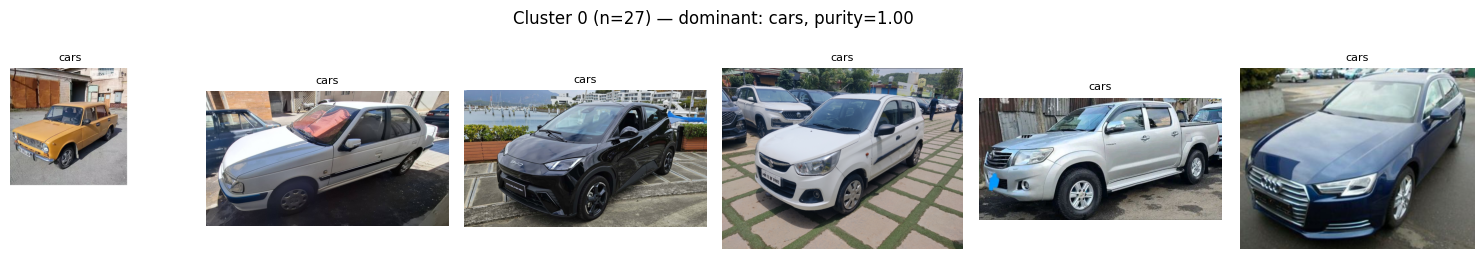

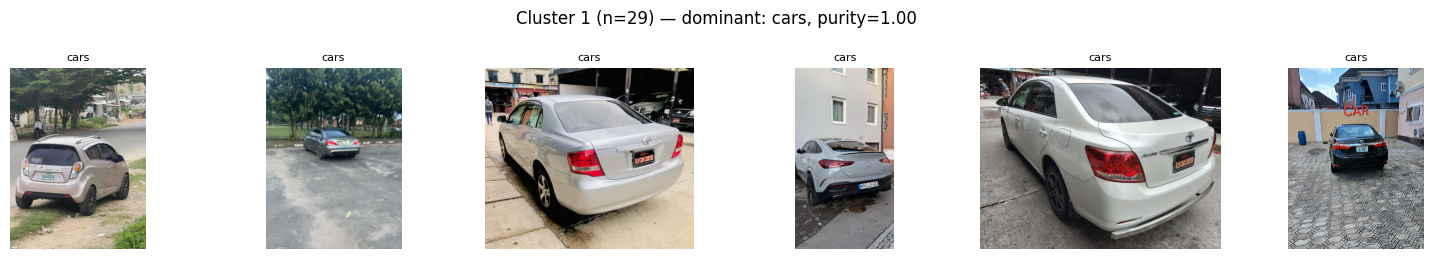

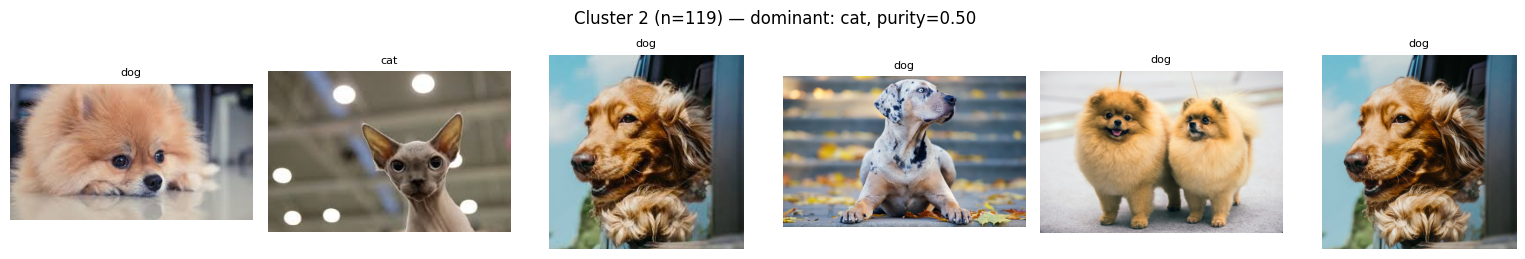

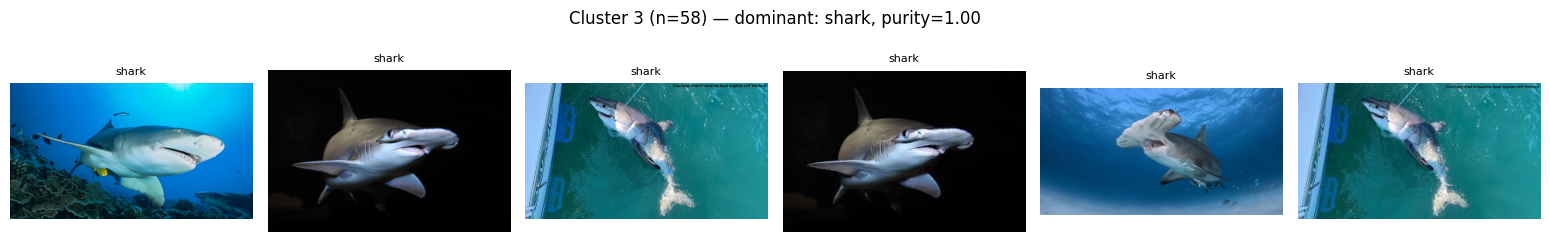

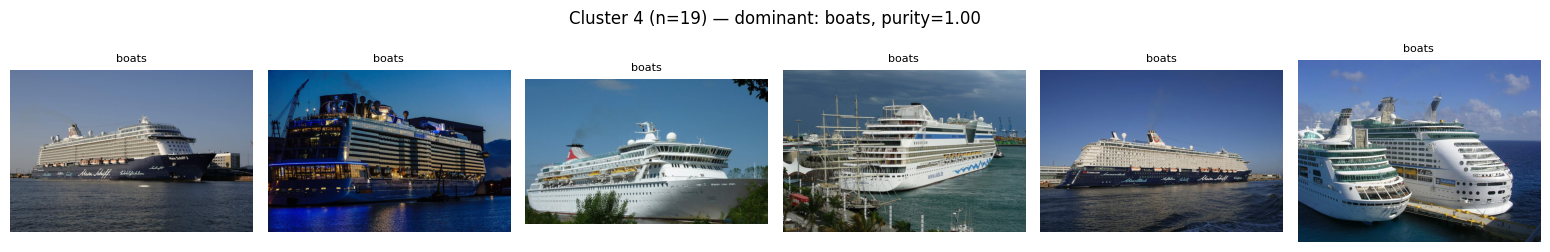

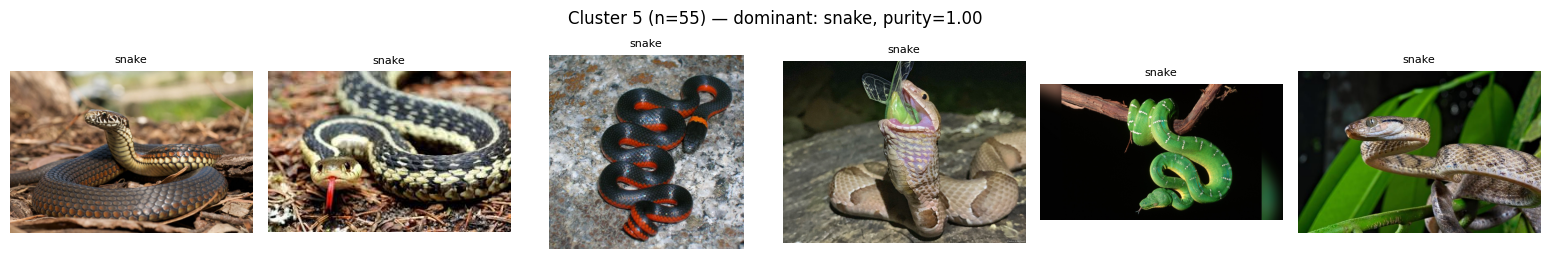

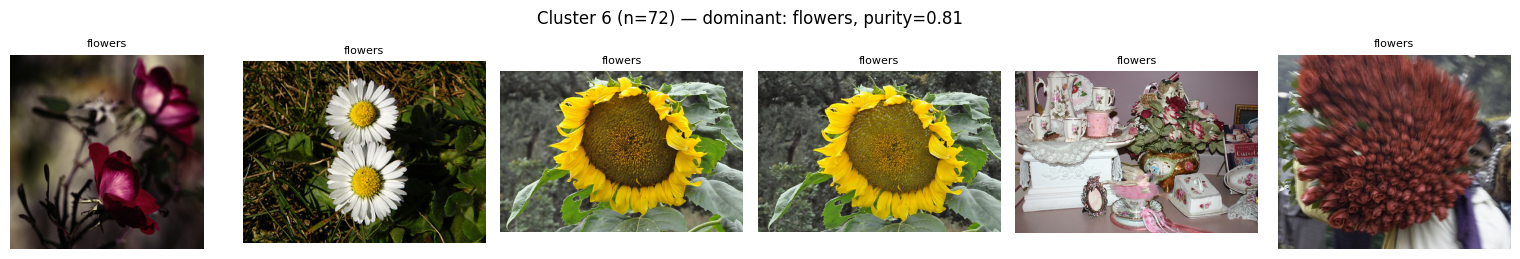

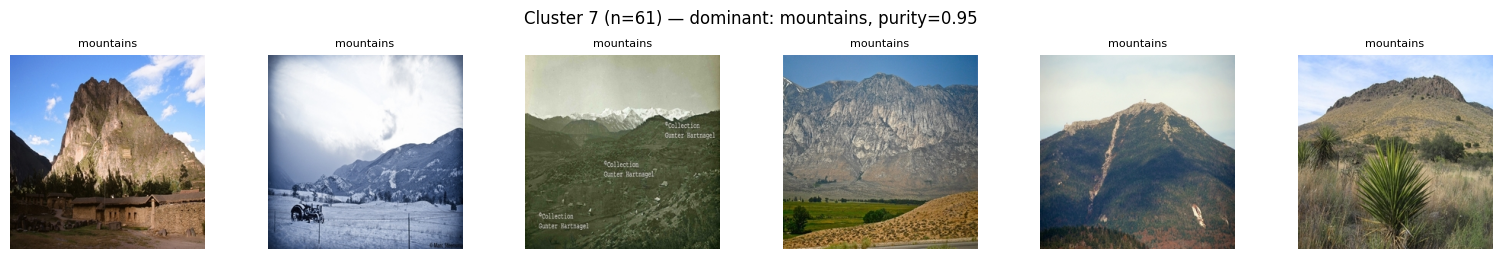

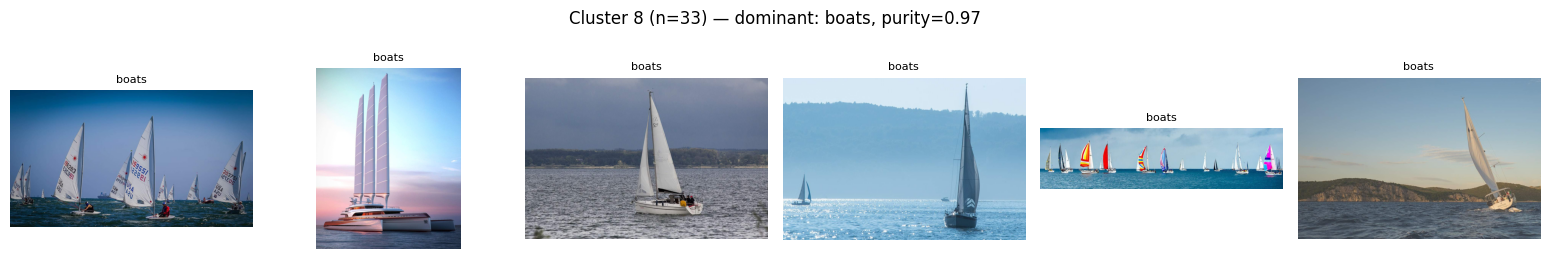

In [48]:
# Select representative images closest to each cluster's centroid in the UMAP-projected space
def get_cluster_representatives(df: pd.DataFrame, features: np.ndarray, cluster_col: str,
                                 cluster_id, top_n: int = 6) -> pd.DataFrame:
    mask = (df[cluster_col] == cluster_id).values
    cluster_features = features[mask]
    cluster_df = df.loc[mask].reset_index(drop=True)
    centroid = cluster_features.mean(axis=0, keepdims=True)
    dists = np.linalg.norm(cluster_features - centroid, axis=1)
    order = np.argsort(dists)[:top_n]
    return cluster_df.iloc[order]


for cid in sorted(c for c in df_controlled["cluster_baseline"].unique() if c != -1):
    reps = get_cluster_representatives(df_controlled, umap_cluster_baseline, "cluster_baseline", cid, top_n=6)
    row = baseline_purity_df[baseline_purity_df["cluster"] == cid]
    dominant = row["dominant_category"].iloc[0] if len(row) else "n/a"
    purity = row["purity"].iloc[0] if len(row) else float("nan")
    size = int((df_controlled["cluster_baseline"] == cid).sum())
    show_image_grid(reps["path"].tolist(),
                     titles=[r.evaluation_category for r in reps.itertuples()],
                     n_cols=6,
                     suptitle=f"Cluster {cid} (n={size}) — dominant: {dominant}, purity={purity:.2f}")


## 15. Parameter Sensitivity

The baseline clustering result is preserved as the primary reference point.

A small parameter sweep evaluates how clustering changes under different:

- UMAP `n_neighbors`
- HDBSCAN `min_cluster_size`
- HDBSCAN `min_samples`

The baseline is not replaced simply because another configuration produces a
higher score.

Any improvement is reported as evidence of parameter sensitivity, not as an
undisputed, universally optimal configuration.


In [49]:
sweep_rows = []
for n_neighbors in [10, 15, 30]:
    umap_variant = compute_umap_projection(
        controlled_embeddings_norm, n_components=CFG.umap_n_components_cluster,
        n_neighbors=n_neighbors, min_dist=0.0, seed=SEED,
    )
    for mcs in [5, 10, 15, 25]:
        for ms in [3, 5, 10]:
            labels, _ = run_hdbscan(umap_variant, min_cluster_size=mcs, min_samples=ms)
            n_c = len(set(labels) - {-1})
            n_n = int((labels == -1).sum())
            metrics = evaluate_clustering(df_controlled["evaluation_category"], labels)
            is_baseline = (n_neighbors == CFG.umap_n_neighbors and mcs == CFG.hdbscan_min_cluster_size
                           and ms == CFG.hdbscan_min_samples)
            sweep_rows.append({
                "umap_n_neighbors": n_neighbors, "hdbscan_min_cluster_size": mcs, "hdbscan_min_samples": ms,
                "n_clusters": n_c, "n_noise": n_n, "pct_noise": round(100 * n_n / len(labels), 1),
                "ARI": metrics["ARI"], "NMI": metrics["NMI"], "is_baseline": is_baseline,
            })

sweep_df = pd.DataFrame(sweep_rows).sort_values("ARI", ascending=False)
print("Full sweep, best ARI first (baseline row flagged in 'is_baseline'):")
display(sweep_df)

sweep_path = CFG.metadata_dir / "controlled_manual_param_sweep.csv"
sweep_df.to_csv(sweep_path, index=False)
print(f"\nSaved -> {sweep_path}")

c:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\venv\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Full sweep, best ARI first (baseline row flagged in 'is_baseline'):


,umap_n_neighbors,hdbscan_min_cluster_size,hdbscan_min_samples,n_clusters,n_noise,pct_noise,ARI,NMI,is_baseline
27,30,10,3,9,8,1.7,0.7656,0.8580,False
25,30,5,5,9,8,1.7,0.7653,0.8561,False
28,30,10,5,9,8,1.7,0.7653,0.8561,False
30,30,15,3,8,18,3.8,0.7637,0.8547,False
31,30,15,5,8,18,3.8,0.7637,0.8561,False
26,30,5,10,8,23,4.8,0.7514,0.8403,False
22,15,25,5,7,26,5.4,0.7490,0.8420,False
17,15,10,10,8,15,3.1,0.7427,0.8372,False
20,15,15,10,8,15,3.1,0.7427,0.8372,False
14,15,5,10,8,15,3.1,0.7427,0.8372,False



Saved -> C:\Users\aryan\OneDrive\Desktop\project_new\semantic-photo-intelligence\data\metadata\controlled_manual_param_sweep.csv


### Interpreting the Parameter Sweep

A substantial difference between the baseline and best-performing
configurations indicates that clustering quality is sensitive to the
UMAP/HDBSCAN configuration.

Therefore, the sweep is used to understand the stability of the clustering
pipeline rather than to cherry-pick a single visually pleasing result. The
best-performing configuration in this sweep is not claimed to be optimal
beyond the parameter grid actually tested.


## 16. Silhouette Analysis

Silhouette score is computed on the original L2-normalized I-JEPA embeddings
using the known category labels.

This provides an additional measure of how well the manually defined
categories are separated in the original embedding space, independently of
the HDBSCAN assignments.

The metric is therefore treated as an auxiliary representation-level
evaluation rather than as the primary clustering metric.


In [50]:
silhouette_on_true_labels = silhouette_score(controlled_embeddings_norm, df_controlled["evaluation_category"], metric="cosine")
print(f"Silhouette score (original normalized embeddings, TRUE category labels, cosine metric): "
      f"{silhouette_on_true_labels:.4f}")
print("Range is [-1, 1]; higher means categories form tighter, better-separated groups in the raw "
      "embedding space. This is independent of HDBSCAN and does not use the UMAP projection.")

Silhouette score (original normalized embeddings, TRUE category labels, cosine metric): 0.1903
Range is [-1, 1]; higher means categories form tighter, better-separated groups in the raw embedding space. This is independent of HDBSCAN and does not use the UMAP projection.


## 17. Results and Observations

The controlled experiment contains **480 valid images across 8 categories,
with 60 images per category**. I-JEPA embeddings are 1280-dimensional.

### Embedding Quality

The I-JEPA embedding extraction completed successfully with the expected
1280-dimensional representation. The embeddings passed the numerical
sanity checks without NaN or infinite values.

### Retrieval

The retrieval sanity check showed strong local semantic structure: the tested
queries retrieved images from the same visual category among their nearest
neighbors.

This indicates that nearby points in the I-JEPA embedding space tend to
represent visually related images.

### Baseline Clustering

The baseline UMAP + HDBSCAN configuration produced:

- **9 clusters** (against 8 known categories — HDBSCAN was not constrained
  to match this number)
- **1.5% noise**
- **ARI: 0.7118**
- **NMI: 0.8239**
- **Mean cluster purity: 0.914**

The clustering therefore recovered substantial category-level structure,
although the discovered clusters did not correspond perfectly to the 8
manually defined categories.

### Parameter Sensitivity

The parameter sweep produced a best tested ARI of **0.7656** (at
`n_neighbors=15`, `min_cluster_size=10`, `min_samples=3`), compared with
the baseline ARI of **0.7118**.

This indicates that clustering quality is meaningfully affected by the
UMAP/HDBSCAN configuration. This best-tested configuration reflects the
specific grid searched here and is not presented as a universally optimal
setting.

### Silhouette

The silhouette score on the original normalized embeddings, using the true
category labels, was approximately **0.1903**.

This is a modest value and indicates that the category structure is not
perfectly separated in the original embedding space, despite the stronger
clustering metrics obtained after UMAP and HDBSCAN.

### Overall Observation

The results indicate that I-JEPA embeddings contain visual structure that
an unsupervised UMAP + HDBSCAN pipeline can recover on this controlled,
manually curated dataset.

This does not establish that arbitrary real-world photograph collections
will automatically form equally clean semantic clusters — see Limitations
below.


## 18. Limitations

- **Small dataset:** 480 images provide a controlled evaluation, but are not
  sufficient to generalize I-JEPA clustering performance to large,
  real-world photo collections.

- **Visually distinct categories:** the selected categories are relatively
  easy to distinguish compared with the overlapping content of personal photo
  libraries.

- **Single model checkpoint:** only `facebook/ijepa_vith14_1k` was evaluated.

- **Clustering dependency:** the experiment relies on UMAP + HDBSCAN, and
  different dimensionality-reduction or clustering methods may produce
  different results.

- **Manually curated categories:** the folder categories represent a single
  manually curated labeling scheme and may contain borderline examples; they
  are used only for evaluation and were never seen by I-JEPA, UMAP, or
  HDBSCAN.

- **Parameter sensitivity:** clustering performance changes with UMAP and
  HDBSCAN parameters, so the reported baseline should not be interpreted as
  an absolute optimum, and the parameter sweep should not be read as proof
  of a universally optimal configuration.

- **Controlled evaluation:** strong results on this dataset do not guarantee
  equally strong album discovery on arbitrary personal photo libraries, and
  HDBSCAN is not expected to always produce exactly 8 clusters on data like
  this.


## 19. Conclusion

This experiment evaluated a complete unsupervised image-organization pipeline
based on pretrained I-JEPA embeddings, asking whether the resulting
representations contain useful visual structure for semantic image
organization.

The results provide evidence for three observations:

1. **I-JEPA embeddings preserve useful local visual similarity.**
   Nearest-neighbor retrieval consistently returned visually related images
   for the tested queries.

2. **The embedding space contains meaningful category-level structure.**
   UMAP projection followed by HDBSCAN clustering recovered substantial
   structure from the manually curated dataset, achieving a baseline ARI of
   **0.7118**, NMI of **0.8239**, and mean cluster purity of **0.914**,
   without ever being given the category labels.

3. **Clustering quality is configuration-dependent.**
   The parameter sweep improved the best tested ARI to **0.7656**, showing
   that UMAP and HDBSCAN parameters have a meaningful effect on the resulting
   cluster structure.

Taken together, these results provide evidence that pretrained I-JEPA
representations carry class-level structure that a fully unsupervised
UMAP + HDBSCAN pipeline can recover under the favorable, controlled
conditions of this dataset. This does not by itself establish that I-JEPA
embeddings are "good" for semantic organization in general, and a modest
silhouette score (0.1903) on the raw embedding space suggests the category
separation is imperfect even here.

The results do not establish that every real-world photo collection will
form clean clusters. Real personal libraries contain overlapping scenes,
multiple objects, ambiguous semantics, and continuous visual variation, and
the categories used here were chosen to be visually distinct. Evaluating
this representation on less controlled, real-world photo collections is
left to future work.


In [51]:
best_sweep_ari = sweep_df["ARI"].max()
best_sweep_row = sweep_df.iloc[sweep_df["ARI"].idxmax()]
sweep_improvement = best_sweep_ari - baseline_metrics["ARI"]

print("=== Results summary ===")
print(f"Baseline:    {n_clusters} clusters, "
      f"{round(100 * (baseline_labels == -1).mean(), 1)}% noise, "
      f"ARI={baseline_metrics['ARI']}, NMI={baseline_metrics['NMI']}, "
      f"mean purity={mean_purity:.3f}" if pd.notna(mean_purity) else "n/a")
print(f"Best sweep configuration:   ARI={best_sweep_ari} "
      f"(n_neighbors={best_sweep_row['umap_n_neighbors']}, "
      f"min_cluster_size={best_sweep_row['hdbscan_min_cluster_size']}, "
      f"min_samples={best_sweep_row['hdbscan_min_samples']})")
print(f"Sweep improvement over baseline ARI: {sweep_improvement:+.4f}")
print(f"Silhouette score (true labels, raw embeddings): {silhouette_on_true_labels:.4f}")
print()
print("Reading of the results -- confirm against the Section 10/11 plots and")
print("Section 13 contingency table before treating any of this as conclusive:")
if baseline_metrics["ARI"] > 0.4 and mean_purity is not None and pd.notna(mean_purity) and mean_purity > 0.7:
    print(" -> Baseline clustering recovers substantial category-level structure on this")
    print("    clean, manually verified, category-balanced dataset without HDBSCAN ever")
    print("    seeing the category labels.")
elif sweep_improvement > 0.15 and baseline_metrics["ARI"] < 0.3:
    print(" -> The baseline was weak, but tuning recovered meaningfully better ARI/NMI,")
    print("    suggesting the pipeline configuration -- not just the representation --")
    print("    plays a substantial role in cluster quality.")
elif baseline_metrics["ARI"] <= 0.15 and best_sweep_ari <= 0.2:
    print(" -> Even a clean, manually labeled, visually distinct 8-category dataset")
    print("    clustered weakly across the sweep, which is evidence against strong")
    print("    global category structure in this embedding space.")
else:
    print(" -> The results are mixed and do not cleanly point in a single direction.")


=== Results summary ===
Baseline:    9 clusters, 1.5% noise, ARI=0.7118, NMI=0.8239, mean purity=0.914
Best sweep configuration:   ARI=0.7656 (n_neighbors=15, min_cluster_size=10, min_samples=3)
Sweep improvement over baseline ARI: +0.0538
Silhouette score (true labels, raw embeddings): 0.1903

Reading of the results -- confirm against the Section 10/11 plots and
Section 13 contingency table before treating any of this as conclusive:
 -> Baseline clustering recovers substantial category-level structure on this
    clean, manually verified, category-balanced dataset without HDBSCAN ever
    seeing the category labels.


## 20. Final Research Questions

1. **Are the manually defined categories visually separable in I-JEPA
   space?** The UMAP projection (Section 10) shows partial visual
   separation between categories, and the silhouette score on the raw
   embeddings (0.1903, Section 16) indicates that separation is present
   but modest.

2. **Does HDBSCAN recover meaningful structure without seeing the
   labels?** Yes: HDBSCAN discovered 9 clusters against 8 known categories
   (Section 11), and the contingency table (Section 13) shows most
   clusters are dominated by a single category.

3. **What are the measured ARI, NMI, and purity values?** Baseline ARI =
   0.7118, NMI = 0.8239, mean cluster purity = 0.914 (Section 12); best
   parameter-sweep ARI = 0.7656 (Section 15).

4. **How sensitive is clustering quality to UMAP/HDBSCAN configuration?**
   The parameter sweep improved ARI by +0.0538 over the baseline across
   the tested grid (Section 15), indicating a meaningful but not dramatic
   sensitivity to configuration within the range tested.

5. **What does this imply for using I-JEPA for automatic album
   discovery?** The results are encouraging for controlled, visually
   distinct categories, but should be read as a moderate-confidence signal
   rather than a general-purpose verdict — see Section 18 for why these
   categories are easier to separate than a typical personal photo
   library.

**These answers should not be treated as a final verdict on I-JEPA.** A
high ARI/NMI on this dataset demonstrates that I-JEPA embeddings *can*
carry class-level structure recoverable by UMAP + HDBSCAN under favorable,
controlled conditions. It does not by itself demonstrate that I-JEPA is
"good" for semantic organization in general, nor would a weak result alone
have proven the representation "bad." Where the evidence is genuinely
mixed, that should be reported as inconclusive rather than resolved by
picking whichever reading the numbers lean toward most narrowly.
